Importation et chargements des dataset

In [8]:
#Importation des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
#Chargement des données

datacat = pd.read_csv('../data/row/category_tree.csv',sep=',')
dataeve = pd.read_csv('../data/row/events.csv',sep=',')
dataitem1 = pd.read_csv('../data/row/item_properties_part1.csv',sep=',')
dataitem2 = pd.read_csv('../data/row/item_properties_part2.csv',sep=',')

Aperçu des données

In [10]:
# Aperçu des données chargées
print("Aperçu des données des catégories :")
print(datacat.head())

print("Aperçu des données des événements :")
print(dataeve.head())

print("Aperçu des données des propriétés des articles (partie 1) :")
print(dataitem1.head())

print("Aperçu des données des propriétés des articles (partie 2) :")
print(dataitem2.head())

Aperçu des données des catégories :
   categoryid  parentid
0        1016     213.0
1         809     169.0
2         570       9.0
3        1691     885.0
4         536    1691.0
Aperçu des données des événements :
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN
Aperçu des données des propriétés des articles (partie 1) :
       timestamp  itemid    property                            value
0  1435460400000  460429  categoryid                             1338
1  1441508400000  206783         888          1116713 960601 n277.200
2  1439089200000  395014         400  n552.000 639502 n720.000 424566
3  1431226800000   59481         790                       n15360.000
4  1431831600000  156781        

In [11]:
#Nombre de lignes et de colonnes dans chaque dataset
print("Nombre de lignes et de colonnes dans chaque dataset :")
print(datacat.shape)
print(dataeve.shape)
print(dataitem1.shape)
print(dataitem2.shape)

Nombre de lignes et de colonnes dans chaque dataset :
(1669, 2)
(2756101, 5)
(10999999, 4)
(9275903, 4)


In [12]:
#les infos des datasets
print("Informations sur les datasets catégories :")
print(datacat.info())

print("Informations sur les datasets événements :")
print(dataeve.info())

print("Informations sur les datasets propriétés des articles (partie 1) :")
print(dataitem1.info())

print("Informations sur les datasets propriétés des articles (partie 2) :")
print(dataitem2.info())

#Vérification des valeurs manquantes
print("Vérification des valeurs manquantes dans les datasets :")
print(datacat.isnull().sum()/len(datacat)*100)
print(dataeve.isnull().sum()/len(dataeve)*100)
print(dataitem1.isnull().sum()/len(dataitem1)*100)
print(dataitem2.isnull().sum()/len(dataitem2)*100)

Informations sur les datasets catégories :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB
None
Informations sur les datasets événements :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB
None
Informations sur les datasets propriétés des articles (partie 1) :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999999 entries, 0 to 10999998
Data columns (total 4 columns):
 #   Column     Dtype 
---  --

Netoyage des donnée

In [13]:
#supprimer les doublons
datacat.drop_duplicates(inplace=True)
dataeve.drop_duplicates(inplace=True)
dataitem1.drop_duplicates(inplace=True)
dataitem2.drop_duplicates(inplace=True) 

print("Après suppression des doublons :")
print("Catégories :", datacat.shape)
print("Événements :", dataeve.shape)
print("Propriétés des articles (partie 1) :", dataitem1.shape)
print("Propriétés des articles (partie 2) :", dataitem2.shape)

Après suppression des doublons :
Catégories : (1669, 2)
Événements : (2755641, 5)
Propriétés des articles (partie 1) : (10999999, 4)
Propriétés des articles (partie 2) : (9275903, 4)


Exploration

In [14]:
#Affichage des premieres ligne de events
print(dataeve.head(10))
#nombre d'événement par type
print('Nombre d\'événement par type:')
print(dataeve['event'].value_counts())

#Nombre de visiteur uniques
print('Nombre de visiteurs uniques:')
print(dataeve['visitorid'].nunique())

#Nombre total d'événements
print('Nombre total d\'événements:')
print(len(dataeve))

       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN
5  1433224086234     972639  view   22556            NaN
6  1433221923240     810725  view  443030            NaN
7  1433223291897     794181  view  439202            NaN
8  1433220899221     824915  view  428805            NaN
9  1433221204592     339335  view   82389            NaN
Nombre d'événement par type:
event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64
Nombre de visiteurs uniques:
1407580
Nombre total d'événements:
2755641


EDA par graphique glogal des évènements

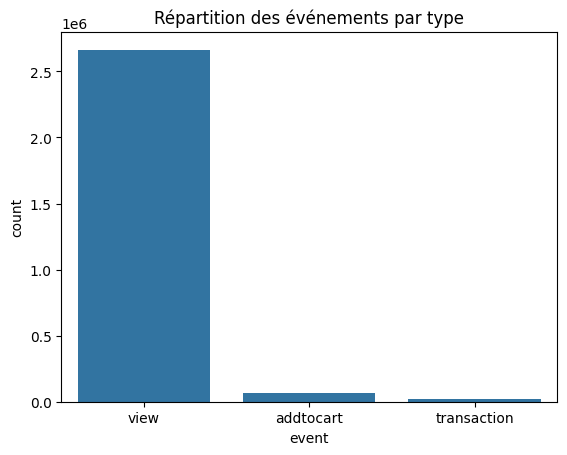

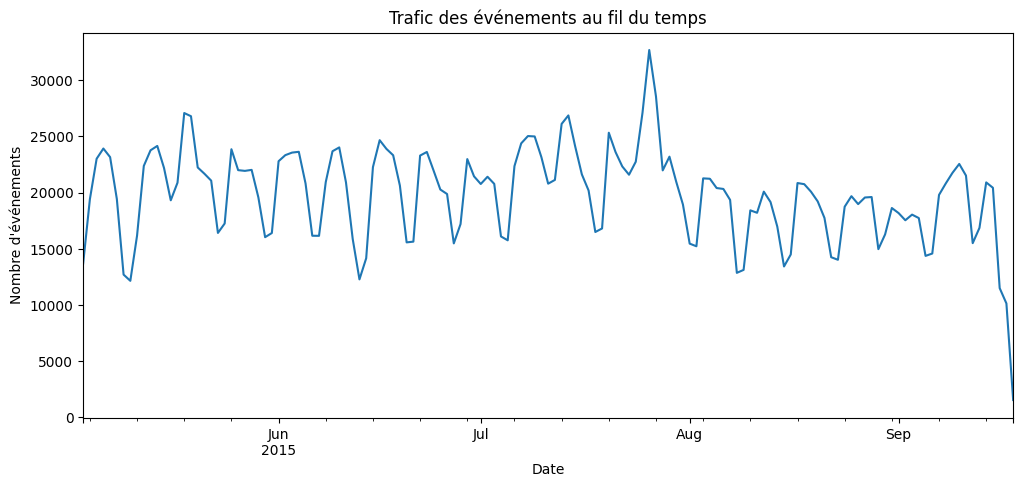

In [19]:
# Répartition des événements par type
sns.countplot(
    x='event',
    order=['view', 'addtocart', 'transaction'],
    data=dataeve
)
plt.title("Répartition des événements par type")
plt.show()

# Trafic des événements au fil du temps

# Conversion du timestamp
dataeve['timestamp'] = pd.to_datetime(dataeve['timestamp'], unit='ms')

# Agrégation journalière
daily_events = (
    dataeve
    .set_index('timestamp')
    .resample('D')['event']
    .count()
)

# Visualisation
daily_events.plot(figsize=(12, 5))
plt.title("Trafic des événements au fil du temps")
plt.xlabel("Date")
plt.ylabel("Nombre d'événements")
plt.show()


Analyse utilisteur comportement

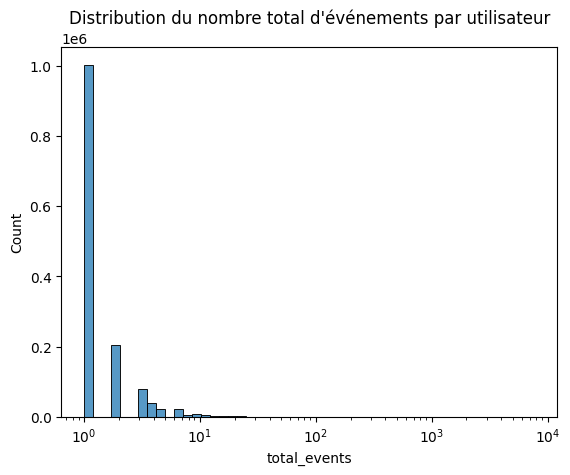

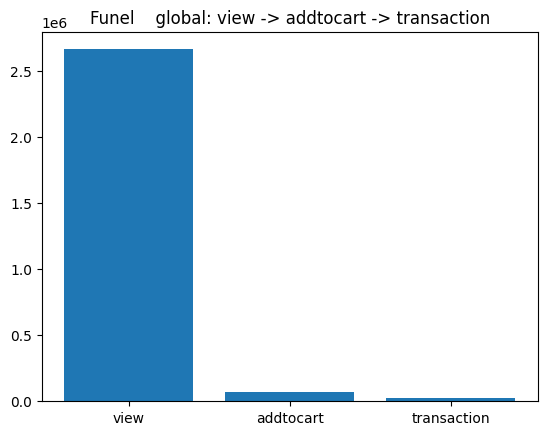

In [ ]:
#Analyse utilisteur comportement
users_sats = dataeve.groupby('visitorid')['event'].value_counts().unstack(fill_value=0)
users_sats['total_events'] = users_sats.sum(axis=1)
users_sats.describe()

#histogramme du nombre total d'événements par utilisateur
sns.histplot(users_sats['total_events'], bins=50, log_scale=True)
plt.title('Distribution du nombre total d\'événements par utilisateur')
plt.show()

#funel visualisation addcart vs transaction
funel = {
    'view':len(dataeve[dataeve['event']=='view']),
    'addtocart':len(dataeve[dataeve['event']=='addtocart']),
    'transaction':len(dataeve[dataeve['event']=='transaction'])
}
plt.bar(funel.keys(), funel.values())
plt.title('Funel    global: view -> addtocart -> transaction')
plt.show()

Annalyse des produits

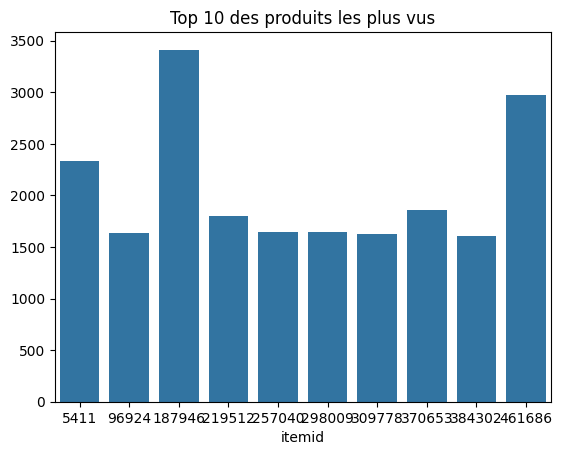

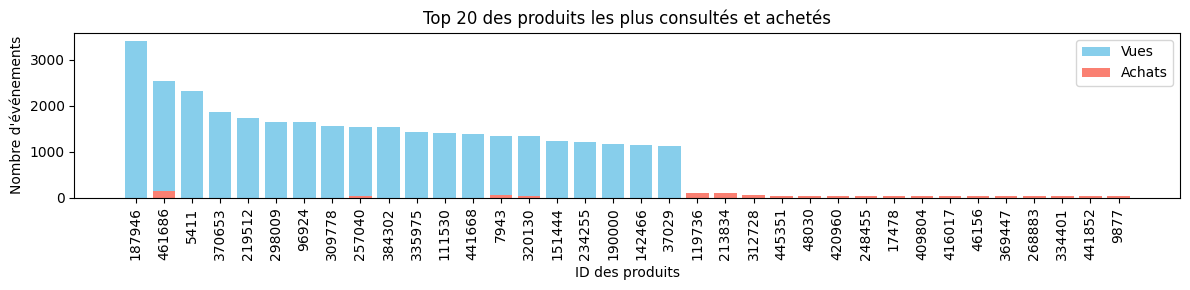

In [ ]:
#annalyse des produits
top_items= dataeve['itemid'].value_counts().head(10)
sns.barplot(x=top_items.index, y=top_items.values)
plt.title('Top 10 des produits les plus vus')
plt.show()

# --- Produits les plus consultés / achetés ---
views = dataeve[dataeve['event'] == 'view']['itemid'].value_counts().head(20)
purchases = dataeve[dataeve['event'] == 'transaction']['itemid'].value_counts().head(20)

# --- Création du graphique ---
plt.figure(figsize=(12,3))

# Graphique pour les vues
plt.bar(views.index.astype(str), views.values, color='skyblue', label='Vues')

# Graphique pour les achats
plt.bar(purchases.index.astype(str), purchases.values, color='salmon', label='Achats')

# --- Personnalisation du graphique ---
plt.title("Top 20 des produits les plus consultés et achetés")
plt.xlabel("ID des produits")
plt.ylabel("Nombre d'événements")
plt.xticks(rotation=90)  # pour mieux lire les ID
plt.legend()
plt.tight_layout()

# --- Affichage ---
plt.show()

Interprétation du graphique

Le graphique montre les 20 produits les plus consultés et les 20 produits les plus achetés sur le site e-commerce.
On observe que le produit ID 187946 est le plus consulté avec environ 3410 vues, ce qui indique un fort intérêt des visiteurs, mais il ne figure pas parmi les plus achetés — cela peut suggérer un problème de conversion (par exemple : prix trop élevé, informations manquantes, ou produit non disponible).
Le produit ID 461686 se distingue particulièrement, car il est à la fois très consulté (2538 vues) et le plus acheté (133 transactions). C’est donc un produit phare, très attractif et performant commercialement.
D’autres produits comme ID 7943 ou ID 320130 apparaissent aussi dans les deux listes, ce qui montre qu’ils plaisent aux clients et se vendent bien.
À l’inverse, certains produits très vus mais peu achetés indiquent des opportunités d’optimisation (description, prix, images, etc.).

In [ ]:
#Produits peu vus et non achetés

# --- Nombre de vues par produit ---
views_count = dataeve[dataeve['event'] == 'view']['itemid'].value_counts()

# --- Nombre d'achats par produit ---
purchases_count = dataeve[dataeve['event'] == 'transaction']['itemid'].value_counts()

# --- Identifier les produits avec très peu de vues (par exemple <=5) et aucun achat ---
low_views = views_count[views_count <= 5]  # produits peu vus
not_purchased = low_views[~low_views.index.isin(purchases_count.index)]  # pas achetés

# --- Afficher les résultats ---
print("Produits peu vus et non achetés :")
print(not_purchased)


Produits peu vus et non achetés :
itemid
251303    5
203775    5
67634     5
352922    5
210917    5
         ..
236179    1
198054    1
248521    1
232057    1
230914    1
Name: count, Length: 154819, dtype: int64


Reimportation des bibliothèques

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import datetime

In [18]:
dfevents =pd.read_csv("../data/row/events.csv" , sep=",")
dfcategorys =pd.read_csv("../data/row/category_tree.csv" , sep=",")
dfitem1 =pd.read_csv("../data/row/item_properties_part1.csv" , sep=",")
dfitem2 =pd.read_csv("../data/row/item_properties_part2.csv" , sep=",")